## Run Hypertunning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import rpy2.robjects as robjects

In [2]:
import importlib
import sys

importlib.invalidate_caches()
for mod in [
    "forecast_research.energy_price.custom_losses",
    "forecast_research.energy_price.helpers",
]:
    if mod in sys.modules:
        del sys.modules[mod]

from forecast_research.energy_price.custom_losses import (
    dirichlet_layer,
    EvidentialLoss,
    AnnealingCallback,
    evidential_kl_divergence,
    cross_entropy_loss,
)

from forecast_research.energy_price.helpers import (
    load_rds_array,
    plot_training_history,
)

2026-04-08 12:45:09.372297: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-08 12:45:21.934003: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775677522.696380  653642 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775677523.228998  653642 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775677525.201627  653642 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Read files in energy_data folder


In [3]:
X_train,     (_, _, feature_names)    = load_rds_array('energy_data/X_train.rds')
Y_train,     (_, _, state_names)      = load_rds_array('energy_data/Y_train.rds')
Y_hat_train, (_, _, state_names_hat)  = load_rds_array('energy_data/Y_hat_train.rds')

X_valid,     _ = load_rds_array('energy_data/X_valid.rds')
Y_valid,     _ = load_rds_array('energy_data/Y_valid.rds')
Y_hat_valid, _ = load_rds_array('energy_data/Y_hat_valid.rds')

X_test,      _ = load_rds_array('energy_data/X_test.rds')
Y_test,      _ = load_rds_array('energy_data/Y_test.rds')
Y_hat_test,  _ = load_rds_array('energy_data/Y_hat_test.rds')

print("X_train:    ", X_train.shape)
print("Y_train:    ", Y_train.shape)
print("Y_hat_train:", Y_hat_train.shape)
print("\nFeature names:", feature_names)
print("State names:  ", state_names)


X_train:     (3510, 10, 14)
Y_train:     (3510, 10, 4)
Y_hat_train: (3510, 10, 4)

Feature names: ['date', 'renewable_penetration', 'renewable_penetration_30d_avg', 'gas_share', 'gas_share_30d_avg', 'coal_share', 'coal_share_30d_avg', 'net_export_ratio', 'relative_demand', 'gas_price', 'month', 'state_prob_1', 'state_prob_2', 'state_prob_3']
State names:   ['date', 'gt_1', 'gt_2', 'gt_3']


### Convert to single forecast training splits

In [14]:
forecast_horizon = Y_train.shape[1]

dt_col_names = ['month']
x_cols       = [i for i, n in enumerate(feature_names) if n != 'date' and n not in dt_col_names]
x_dt_cols    = [i for i, n in enumerate(feature_names) if n in dt_col_names]
y_cols       = [i for i, n in enumerate(state_names)   if n != 'date']
x_date_idx   = feature_names.index('date')
y_date_idx   = state_names.index('date')

def prepare_data_with_horizon(X, Y, shuffle=True):
    x_dates = X[:, :, x_date_idx]
    y_dates = Y[:, :, y_date_idx]

    X_cov = X[:, :, x_cols].astype(float)
    X_dt  = X[:, :, x_dt_cols].astype(float)
    Y     = Y[:, :, y_cols].astype(float)

    n_samples = X_cov.shape[0]

    horizon_input = np.repeat(np.eye(forecast_horizon), n_samples, axis=0)
    X_cov_out     = np.concatenate([X_cov] * forecast_horizon, axis=0)
    X_dt_out      = np.concatenate([X_dt]  * forecast_horizon, axis=0)
    Y_out         = np.concatenate([Y[:, i, :] for i in range(forecast_horizon)], axis=0)
    x_dates_out   = np.tile(x_dates, (forecast_horizon, 1))[:, :, np.newaxis]
    y_dates_out   = np.concatenate([y_dates[:, i] for i in range(forecast_horizon)])[:, np.newaxis]
    y_month_out   = pd.get_dummies(pd.to_datetime(y_dates_out.flatten()).month, prefix='month').values.astype(int)

    if shuffle:
        idx           = np.random.permutation(X_cov_out.shape[0])
        X_cov_out     = X_cov_out[idx]
        X_dt_out      = X_dt_out[idx]
        horizon_input = horizon_input[idx]
        Y_out         = Y_out[idx]
        x_dates_out   = x_dates_out[idx]
        y_dates_out   = y_dates_out[idx]
        y_month_out   = y_month_out[idx]


    return X_cov_out, X_dt_out, horizon_input, Y_out, x_dates_out, y_dates_out, y_month_out

X_train_cov, X_train_dt, horizon_train, Y_train_h, dates_train, Y_dates_train, Y_month_train = prepare_data_with_horizon(X_train, Y_train, shuffle=True)
X_valid_cov, X_valid_dt, horizon_valid, Y_valid_h, dates_valid, Y_dates_valid, Y_month_valid = prepare_data_with_horizon(X_valid, Y_valid, shuffle=False)
X_test_cov,  X_test_dt,  horizon_test,  Y_test_h,  dates_test,  Y_dates_test, Y_month_test  = prepare_data_with_horizon(X_test,  Y_test,  shuffle=False)

print("X_train_cov:  ", X_train_cov.shape)   # (samples*horizon, lookback, 12)
print("X_train_dt:   ", X_train_dt.shape)    # (samples*horizon, lookback, 2)
print("horizon_train:", horizon_train.shape)  # (samples*horizon, horizon)
print("Y_train_h:    ", Y_train_h.shape)      # (samples*horizon, states)
print("Y_month_train:", Y_month_train.shape)     # (samples*horizon, 1)
print()
print("Cov features: ", [n for n in feature_names if n != 'date' and n not in dt_col_names])
print("DT features:  ", dt_col_names)


X_train_cov:   (35100, 10, 12)
X_train_dt:    (35100, 10, 1)
horizon_train: (35100, 10)
Y_train_h:     (35100, 3)
Y_month_train: (35100, 12)

Cov features:  ['renewable_penetration', 'renewable_penetration_30d_avg', 'gas_share', 'gas_share_30d_avg', 'coal_share', 'coal_share_30d_avg', 'net_export_ratio', 'relative_demand', 'gas_price', 'state_prob_1', 'state_prob_2', 'state_prob_3']
DT features:   ['month']


In [5]:
import os
import numpy as np

# Create the new folder if it doesn't exist
os.makedirs('energy_data/ml_data', exist_ok=True)

# Save X_train_cov
np.save('energy_data/ml_data/X_train_cov.npy', X_train_cov)
np.save('energy_data/ml_data/X_train_dt.npy', X_train_dt)
np.save('energy_data/ml_data/horizon_train.npy', horizon_train)
np.save('energy_data/ml_data/Y_train_h.npy', Y_train_h)
np.save('energy_data/ml_data/dates_train.npy', dates_train)
np.save('energy_data/ml_data/Y_dates_train.npy', Y_dates_train)
np.save('energy_data/ml_data/Y_month_train.npy', Y_month_train)

# Save X_valid_cov
np.save('energy_data/ml_data/X_valid_cov.npy', X_valid_cov)
np.save('energy_data/ml_data/X_valid_dt.npy', X_valid_dt)
np.save('energy_data/ml_data/horizon_valid.npy', horizon_valid)
np.save('energy_data/ml_data/Y_valid_h.npy', Y_valid_h)
np.save('energy_data/ml_data/dates_valid.npy', dates_valid)
np.save('energy_data/ml_data/Y_dates_valid.npy', Y_dates_valid)
np.save('energy_data/ml_data/Y_month_valid.npy', Y_month_valid)

# Save Y_month_test
np.save('energy_data/ml_data/X_test_cov.npy', X_test_cov)
np.save('energy_data/ml_data/X_test_dt.npy', X_test_dt)
np.save('energy_data/ml_data/horizon_test.npy', horizon_test)
np.save('energy_data/ml_data/Y_test_h.npy', Y_test_h)
np.save('energy_data/ml_data/dates_test.npy', dates_test)
np.save('energy_data/ml_data/Y_dates_test.npy', Y_dates_test)
np.save('energy_data/ml_data/Y_month_test.npy', Y_month_test)

print("Data saved to energy_data/ml_data/")

Data saved to energy_data/ml_data/


## Create custom Dirichlet layer and callbacks

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
from tensorflow.keras.losses import kullback_leibler_divergence
from tensorflow.keras.layers import Concatenate

### Create the model
Using RNN layer, followed by 2 dense ouput layers with callbacks

In [7]:
def build_model(lookback, n_cov_features, n_dt_features, n_states,
                loss_type='mse', 
                embedding_dim=8, rnn_units=8, n_dense_layers=2, dense_units=16,
                dropout_rate=0.5, learning_rate=0.0001, l2_reg=1e-4, 
                annealing_rate=100.0, max_annealing_rate=0):

    # Covariate time-series input: (lookback, n_cov_features)
    cov_input     = layers.Input(shape=(lookback, n_cov_features), name='cov_input')
    # Date/time input: (lookback, n_dt_features) — flatten across time before embedding
    dt_input      = layers.Input(shape=(n_dt_features, ),  name='dt_input')
    # One-hot horizon input: (forecast_horizon,)
    horizon_input = layers.Input(shape=(forecast_horizon,),        name='horizon_input')

    # Flatten dt across time then project to embedding
    dt_flat  = layers.Flatten()(dt_input)
    dt_embed = layers.Dense(4, activation='relu')(dt_flat)

    # Project horizon to embedding
    horizon_embed = layers.Dense(embedding_dim, activation='relu')(horizon_input)

    # RNN over covariate time-series
    rnn_out = layers.SimpleRNN(rnn_units, dropout=dropout_rate, kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(cov_input)

    # Merge all representations
    x = Concatenate()([rnn_out, dt_embed, horizon_embed])

    # Variable-depth dense head — training=True keeps dropout active at test time (MC Dropout)
    for _ in range(n_dense_layers):
        x = layers.Dense(dense_units, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(x)
        x = layers.Dropout(dropout_rate)(x)

    # Output raw evidence (non-negative) — softplus ensures > 0
    if loss_type == 'cross_entropy':
        output = layers.Dense(n_states, activation='softmax')(x)
    else:
        output = layers.Dense(n_states, activation='relu')(x)

    model = models.Model(inputs=[cov_input, dt_input, horizon_input], outputs=output)
    model.compile(
        loss=EvidentialLoss(loss_type=loss_type, annealing_rate=annealing_rate, max_annealing_rate=max_annealing_rate),
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=[evidential_kl_divergence, cross_entropy_loss]
    )
    return model


# Derive dimensions from prepared arrays
lookback       = X_train_cov.shape[1]
n_cov_features = X_train_cov.shape[2]
n_dt_features  = Y_month_train.shape[1]
n_states       = Y_train_h.shape[1]

model = build_model(lookback, n_cov_features, n_dt_features, n_states,
                    loss_type='cross_entropy',
                    embedding_dim=8, rnn_units=8, n_dense_layers=1, dense_units=16,
                    dropout_rate=0.3, learning_rate=0.0001,
                    annealing_rate=100.0, max_annealing_rate=0)
model.summary()

I0000 00:00:1775677689.423564  653642 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 8074 MB memory:  -> device: 0, name: NVIDIA H100 80GB HBM3 MIG 1g.10gb, pci bus id: 0000:4c:00.0, compute capability: 9.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ dt_input            │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cov_input           │ (None, 10, 12)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 12)        │          0 │ dt_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ horizon_input       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 8)         │        168 │ cov_input[0][0]   │
│ (SimpleRNN)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │         52 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8)         │         88 │ horizon_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 20)        │          0 │ simple_rnn[0][0], │
│ (Concatenate)       │                   │            │ dense[0][0],      │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        336 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 3)         │         51 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 695 (2.71 KB)

 Trainable params: 695 (2.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60


I0000 00:00:1775630414.338816 3289457 service.cc:152] XLA service 0x146a24004060 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775630414.338846 3289457 service.cc:160]   StreamExecutor device (0): NVIDIA H100 80GB HBM3 MIG 1g.10gb, Compute Capability 9.0
I0000 00:00:1775630414.338849 3289457 service.cc:160]   StreamExecutor device (1): NVIDIA H100 80GB HBM3 MIG 1g.10gb, Compute Capability 9.0
I0000 00:00:1775630414.338851 3289457 service.cc:160]   StreamExecutor device (2): NVIDIA H100 80GB HBM3 MIG 1g.10gb, Compute Capability 9.0
I0000 00:00:1775630414.338852 3289457 service.cc:160]   StreamExecutor device (3): NVIDIA H100 80GB HBM3 MIG 1g.10gb, Compute Capability 9.0
2026-04-07 23:40:14.481947: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775630414.816404 3289457 cuda_dnn.cc:529] Loaded cuDNN version 91000


  98/1097 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - cross_entropy_loss: 1.1032 - evidential_kl_divergence: 0.7051 - loss: 1.1405

I0000 00:00:1775630416.346893 3289457 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1097/1097 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - cross_entropy_loss: 1.0912 - evidential_kl_divergence: 0.6883 - loss: 1.0932 - val_cross_entropy_loss: 1.0818 - val_evidential_kl_divergence: 0.6349 - val_loss: 1.0494
Epoch 2/60
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 1.0792 - evidential_kl_divergence: 0.6763 - loss: 1.0521 - val_cross_entropy_loss: 1.0712 - val_evidential_kl_divergence: 0.6243 - val_loss: 1.0132
Epoch 3/60
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 1.0660 - evidential_kl_divergence: 0.6630 - loss: 1.0148 - val_cross_entropy_loss: 1.0618 - val_evidential_kl_divergence: 0.6150 - val_loss: 0.9895
Epoch 4/60
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 1.0579 - evidential_kl_divergence: 0.6549 - loss: 0.9974 - val_cross_entropy_loss: 1.0572 - val_evidential_kl_divergence: 0.6104 - val_loss: 0.9807
Epoch 5/60
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 1.0553 - evidential_kl_divergence: 0.65

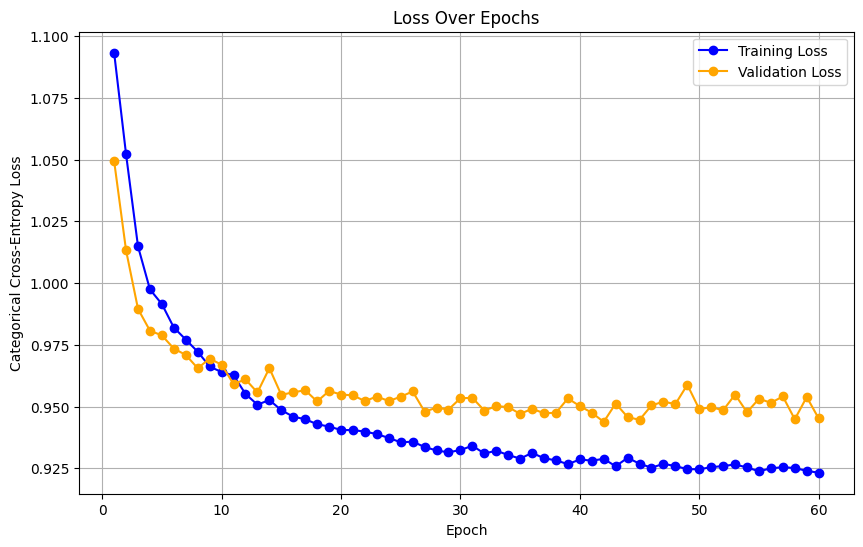

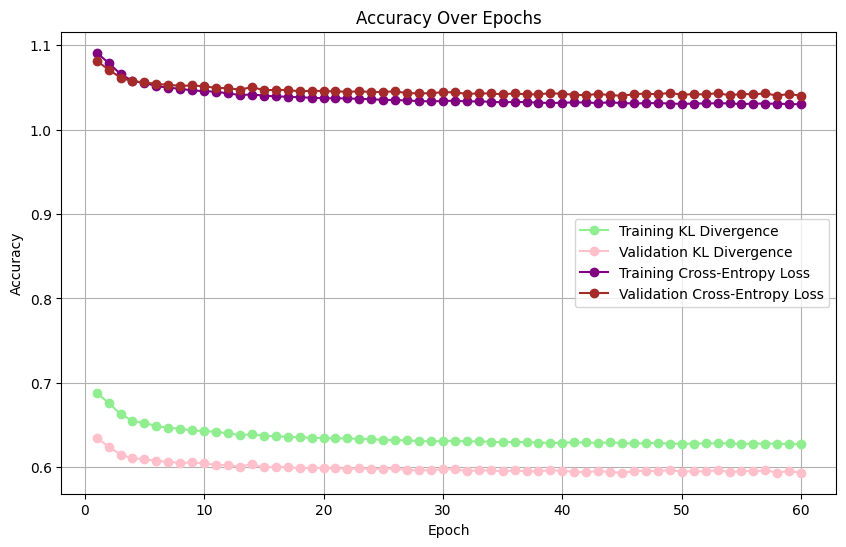

In [8]:

tf.keras.backend.clear_session()

history = model.fit(
    [X_train_cov, Y_month_train, horizon_train], Y_train_h,
    validation_data=([X_valid_cov, Y_month_valid, horizon_valid], Y_valid_h),
    callbacks=[AnnealingCallback()],
    epochs=60,  # Use the same number as in your tuner setup
    verbose=1  # Set to 0 for silent output if preferred
)

def plot_training_history(history):
    epochs = range(1, len(history.history['loss']) + 1)
    
    # Plot Loss
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history.history['loss'], label='Training Loss', marker='o', color='blue')
    plt.plot(epochs, history.history['val_loss'], label='Validation Loss', marker='o', color='orange')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Categorical Cross-Entropy Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Plot Accuracy
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history.history['evidential_kl_divergence'], label='Training KL Divergence', marker='o', color='lightgreen')
    plt.plot(epochs, history.history['val_evidential_kl_divergence'], label='Validation KL Divergence', marker='o', color='pink')
    plt.plot(epochs, history.history['cross_entropy_loss'], label='Training Cross-Entropy Loss', marker='o', color='purple')
    plt.plot(epochs, history.history['val_cross_entropy_loss'], label='Validation Cross-Entropy Loss', marker='o', color='brown')
    plt.title('Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()
    
plot_training_history(history)

## Run Hypertunnig

In [10]:
tf.keras.backend.clear_session()

def build_model_hp(hp):
    return build_model(
        lookback           = lookback,
        n_cov_features     = n_cov_features,
        n_dt_features      = n_dt_features,
        n_states           = n_states,
        embedding_dim      = hp.Choice('embedding_dim',      values=[2, 8]),
        rnn_units          = hp.Choice('rnn_units',          values=[2, 4, 8, 16, 32]),
        n_dense_layers     = hp.Int(  'n_dense_layers',      min_value=1, max_value=3),
        dense_units        = hp.Choice('dense_units',        values=[2, 4, 8, 16]),
        dropout_rate       = hp.Float('dropout_rate',        min_value=0.3, max_value=0.5, step=0.1),
        learning_rate      = hp.Choice('learning_rate',      values=[1e-3, 1e-4]),
        l2_reg             = hp.Choice('l2_reg',              values=[1e-5, 1e-4, 1e-3])
    )


tuner = kt.Hyperband(
    build_model_hp,
    objective=kt.Objective('val_cross_entropy_loss', direction='min'),
    max_epochs=60,
    factor=3,
    overwrite=True,
    directory='tuner_results',
    project_name='energy_hmm',
)

tuner.search(
    [X_train_cov, Y_month_train, horizon_train], Y_train_h,
    validation_data=([X_valid_cov, Y_month_valid, horizon_valid], Y_valid_h),
    callbacks=[AnnealingCallback()],
)

tuner.results_summary()
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(best_hps.values)

# Retrieve the top 10 trials from the tuner's oracle, sorted by the objective (lowest val_cross_entropy_loss)
best_trials = tuner.oracle.get_best_trials(num_trials=20)

# Prepare a list to hold the data for the DataFrame
data = []

# Iterate over each trial to extract hyperparameters and score
for trial in best_trials:
    # Copy the hyperparameter values as a dictionary
    hp_values = trial.hyperparameters.values.copy()
    # Add the score (val_cross_entropy_loss) to the dictionary
    hp_values['val_cross_entropy_loss'] = trial.score
    # Append to the list
    data.append(hp_values)

# Create the DataFrame from the list of dictionaries
df = pd.DataFrame(data)

# Optionally, sort or reorder columns if needed (e.g., move score to the front)
df = df[['val_cross_entropy_loss'] + [col for col in df.columns if col != 'val_cross_entropy_loss']]

# Display or save the DataFrame
df

Trial 90 Complete [00h 02m 20s]
val_cross_entropy_loss: 1.0464096069335938

Best val_cross_entropy_loss So Far: 0.9212884306907654
Total elapsed time: 00h 54m 52s
Results summary
Results in tuner_results/energy_hmm
Showing 10 best trials
Objective(name="val_cross_entropy_loss", direction="min")

Trial 0050 summary
Hyperparameters:
embedding_dim: 2
rnn_units: 32
n_dense_layers: 1
dense_units: 16
dropout_rate: 0.3
learning_rate: 0.0001
l2_reg: 0.001
tuner/epochs: 60
tuner/initial_epoch: 20
tuner/bracket: 3
tuner/round: 3
tuner/trial_id: 0046
Score: 0.9212884306907654

Trial 0018 summary
Hyperparameters:
embedding_dim: 8
rnn_units: 32
n_dense_layers: 1
dense_units: 4
dropout_rate: 0.5
learning_rate: 0.001
l2_reg: 1e-05
tuner/epochs: 3
tuner/initial_epoch: 0
tuner/bracket: 3
tuner/round: 0
Score: 0.9400745630264282

Trial 0082 summary
Hyperparameters:
embedding_dim: 8
rnn_units: 16
n_dense_layers: 1
dense_units: 8
dropout_rate: 0.3
learning_rate: 0.0001
l2_reg: 0.001
tuner/epochs: 60
tuner

,val_cross_entropy_loss,embedding_dim,rnn_units,n_dense_layers,dense_units,dropout_rate,learning_rate,l2_reg,tuner/epochs,tuner/initial_epoch,tuner/bracket,tuner/round,tuner/trial_id
0,0.921288,2,32,1,16,0.3,0.0001,0.00100,60,20,3,3,0046
1,0.940075,8,32,1,4,0.5,0.0010,0.00001,3,0,3,0,NaN
2,0.940716,8,16,1,8,0.3,0.0001,0.00100,60,20,1,1,0077
3,0.941143,8,16,1,8,0.3,0.0001,0.00100,20,0,1,0,NaN
4,0.943959,2,32,1,16,0.3,0.0001,0.00100,20,7,3,2,0041
5,0.951236,2,16,1,4,0.3,0.0010,0.00100,60,0,0,0,NaN
6,0.951981,2,32,1,16,0.3,0.0001,0.00100,7,3,3,1,0005
7,0.952661,8,4,1,8,0.3,0.0010,0.00100,60,20,3,3,0049
8,0.953511,8,16,3,4,0.4,0.0001,0.00001,60,20,2,2,0071
9,0.953564,2,8,3,8,0.3,0.0001,0.00100,7,3,3,1,0008


Epoch 1/90


I0000 00:00:1775677836.509422  660990 service.cc:152] XLA service 0x13a70e60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775677836.525778  660990 service.cc:160]   StreamExecutor device (0): NVIDIA H100 80GB HBM3 MIG 1g.10gb, Compute Capability 9.0
2026-04-08 12:50:38.067398: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775677840.893925  660990 cuda_dnn.cc:529] Loaded cuDNN version 91000
2026-04-08 12:50:44.300664: W external/local_xla/xla/stream_executor/gpu/redzone_allocator_kernel_cuda.cc:135] NOT_FOUND: Couldn't find a suitable version of ptxas. The following locations were considered: bin/ptxas, /project/rrg-kmsmith/dcs01/forecast_research/finance/ptxas, /cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v4/Compiler/gcccore/python/3.12.4/bin/ptxas, /cvmfs/soft.computecanada.ca/easybuild/softwa

  88/1097 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - cross_entropy_loss: 1.0824 - evidential_kl_divergence: 0.6793 - loss: 1.1645

I0000 00:00:1775677845.966645  660990 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1097/1097 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - cross_entropy_loss: 1.0715 - evidential_kl_divergence: 0.6685 - loss: 1.0758 - val_cross_entropy_loss: 1.0695 - val_evidential_kl_divergence: 0.6227 - val_loss: 1.0409
Epoch 2/90
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 1.0528 - evidential_kl_divergence: 0.6498 - loss: 1.0153 - val_cross_entropy_loss: 1.0587 - val_evidential_kl_divergence: 0.6119 - val_loss: 1.0172
Epoch 3/90
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 1.0464 - evidential_kl_divergence: 0.6434 - loss: 0.9977 - val_cross_entropy_loss: 1.0574 - val_evidential_kl_divergence: 0.6105 - val_loss: 1.0106
Epoch 4/90
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 1.0431 - evidential_kl_divergence: 0.6402 - loss: 0.9867 - val_cross_entropy_loss: 1.0534 - val_evidential_kl_divergence: 0.6065 - val_loss: 0.9980
Epoch 5/90
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 1.0410 - evidential_kl_divergence: 0.6

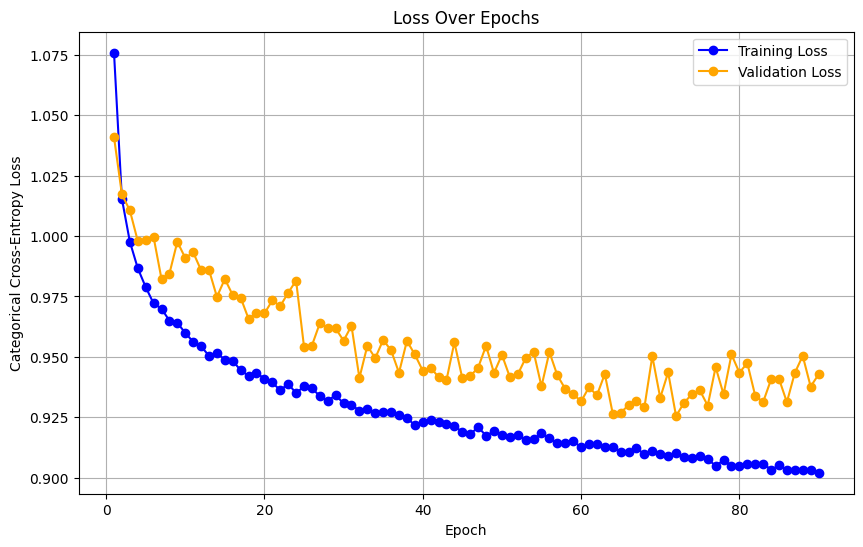

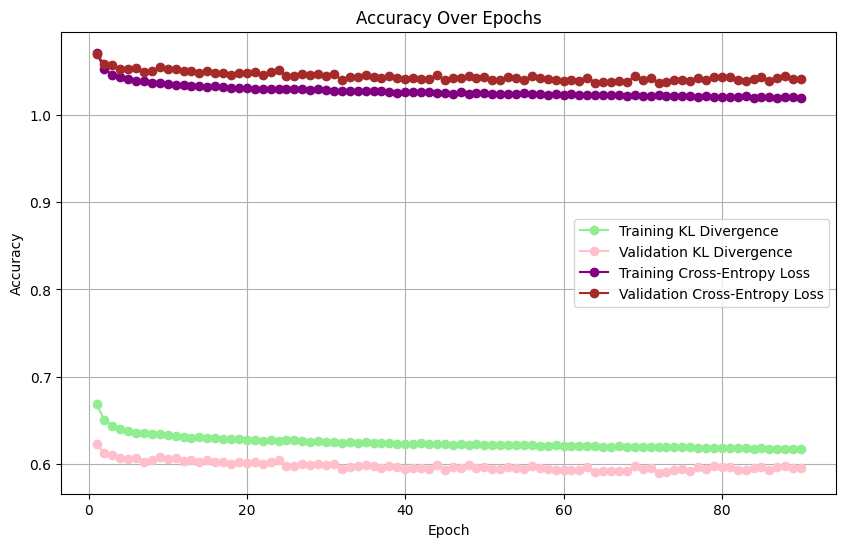

In [9]:
tf.keras.backend.clear_session()

model = build_model(lookback, n_cov_features, n_dt_features, n_states,
                    loss_type='cross_entropy',
                    embedding_dim=2, rnn_units=32, n_dense_layers=1, dense_units=16,
                    dropout_rate=0.3, learning_rate=0.0001, l2_reg=0.001,
                    annealing_rate=100.0, max_annealing_rate=0)

history = model.fit(
    [X_train_cov, Y_month_train, horizon_train], Y_train_h,
    validation_data=([X_valid_cov, Y_month_valid, horizon_valid], Y_valid_h),
    callbacks=[AnnealingCallback()],
    epochs=90,  # Use the same number as in your tuner setup
    verbose=1  # Set to 0 for silent output if preferred
)

def plot_training_history(history):
    epochs = range(1, len(history.history['loss']) + 1)
    
    # Plot Loss
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history.history['loss'], label='Training Loss', marker='o', color='blue')
    plt.plot(epochs, history.history['val_loss'], label='Validation Loss', marker='o', color='orange')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Categorical Cross-Entropy Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Plot Accuracy
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history.history['evidential_kl_divergence'], label='Training KL Divergence', marker='o', color='lightgreen')
    plt.plot(epochs, history.history['val_evidential_kl_divergence'], label='Validation KL Divergence', marker='o', color='pink')
    plt.plot(epochs, history.history['cross_entropy_loss'], label='Training Cross-Entropy Loss', marker='o', color='purple')
    plt.plot(epochs, history.history['val_cross_entropy_loss'], label='Validation Cross-Entropy Loss', marker='o', color='brown')
    plt.title('Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()
    
plot_training_history(history)

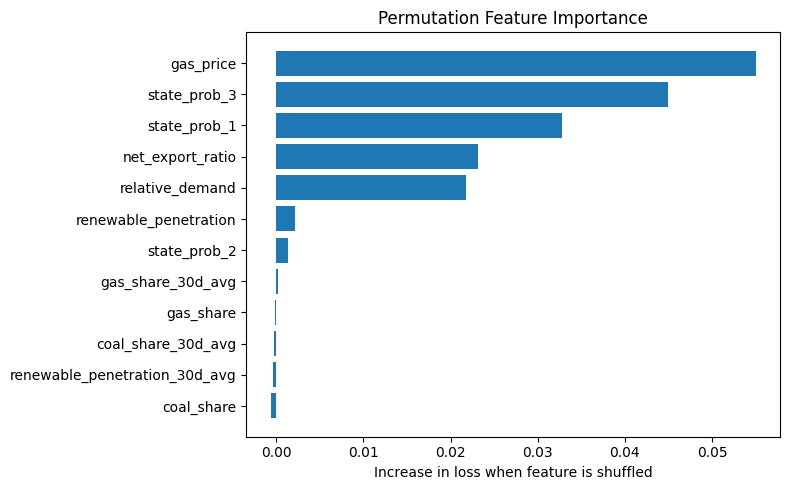

In [10]:
best_model = model
cov_feature_names = [n for n in feature_names if n != 'date' and n not in dt_col_names]

base_loss = best_model.evaluate(
    [X_valid_cov, Y_month_valid, horizon_valid], Y_valid_h, verbose=0
)[0]

importances = {}
for i, name in enumerate(cov_feature_names):
    X_perm = X_valid_cov.copy()
    np.random.shuffle(X_perm[:, :, i])  # shuffle that feature across samples
    perm_loss = best_model.evaluate(
        [X_perm, Y_month_valid, horizon_valid], Y_valid_h, verbose=0
    )[0]
    importances[name] = perm_loss - base_loss

# Plot
names, scores = zip(*sorted(importances.items(), key=lambda x: x[1], reverse=True))
plt.figure(figsize=(8, 5))
plt.barh(names[::-1], scores[::-1])
plt.xlabel("Increase in loss when feature is shuffled")
plt.title("Permutation Feature Importance")
plt.tight_layout()
plt.show()



# Drop Irrelevent Columns

In [15]:
total_cov = [feat for feat in feature_names if feat != 'date' and feat not in dt_col_names]
new_covs = ['net_export_ratio', 'relative_demand', 'gas_price', 'state_prob_1', 'state_prob_2', 'state_prob_3']
new_covs_idx = [total_cov.index(cov) for cov in new_covs]
X_train_cov_new = X_train_cov[:, :, new_covs_idx]
X_valid_cov_new = X_valid_cov[:, :, new_covs_idx]
X_test_cov_new  = X_test_cov[:, :, new_covs_idx]

lookback       = X_train_cov_new.shape[1]
n_cov_features = X_train_cov_new.shape[2]
n_dt_features  = Y_month_train.shape[1]
n_states       = Y_train_h.shape[1]

Epoch 1/30
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 1.0212 - evidential_kl_divergence: 0.6182 - loss: 0.9060 - val_cross_entropy_loss: 1.0356 - val_evidential_kl_divergence: 0.5888 - val_loss: 0.9271
Epoch 2/30
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 1.0202 - evidential_kl_divergence: 0.6172 - loss: 0.9033 - val_cross_entropy_loss: 1.0372 - val_evidential_kl_divergence: 0.5904 - val_loss: 0.9393
Epoch 3/30
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 1.0207 - evidential_kl_divergence: 0.6177 - loss: 0.9045 - val_cross_entropy_loss: 1.0364 - val_evidential_kl_divergence: 0.5895 - val_loss: 0.9306
Epoch 4/30
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 1.0208 - evidential_kl_divergence: 0.6179 - loss: 0.9041 - val_cross_entropy_loss: 1.0376 - val_evidential_kl_divergence: 0.5907 - val_loss: 0.9322
Epoch 5/30
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 1.0208 - evidential_kl_diver

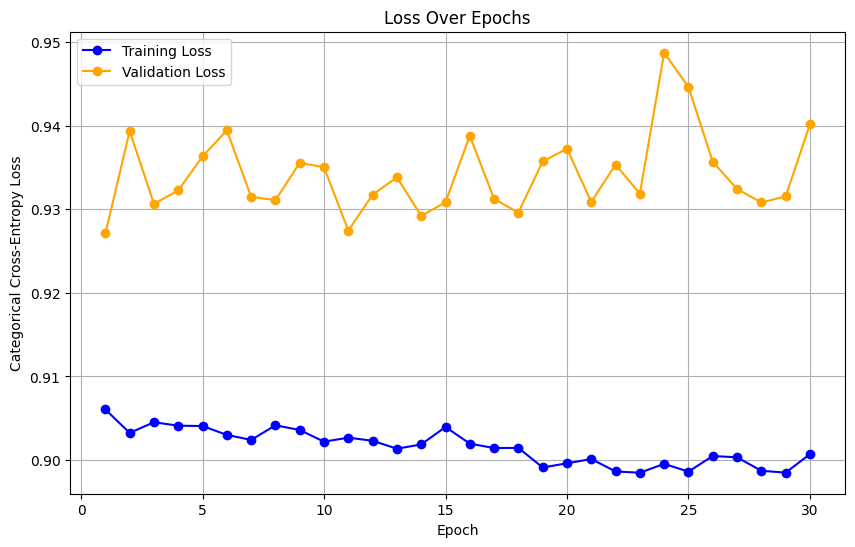

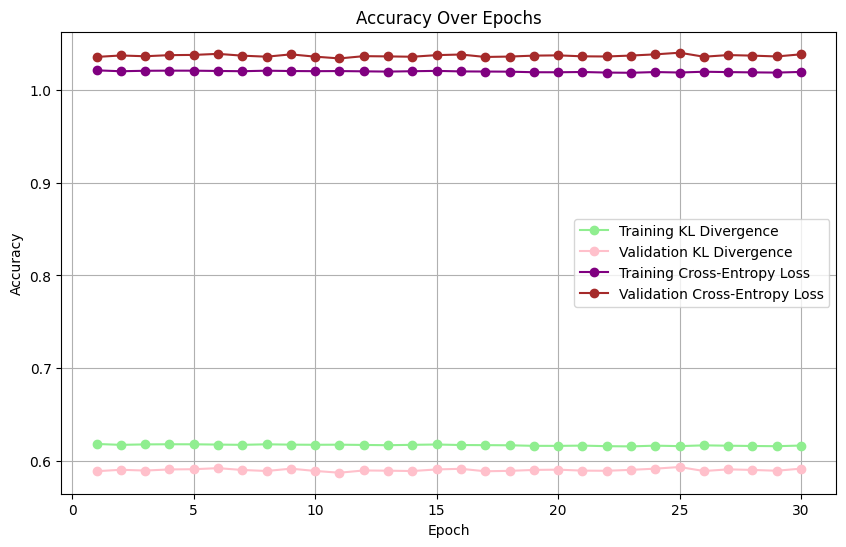

In [ ]:
tf.keras.backend.clear_session()

model = build_model(lookback, n_cov_features, n_dt_features, n_states,
                    loss_type='cross_entropy',
                    embedding_dim=2, rnn_units=32, n_dense_layers=1, dense_units=16,
                    dropout_rate=0.3, learning_rate=0.0001, l2_reg=0.001,
                    annealing_rate=100.0, max_annealing_rate=0)

history = model.fit(
    [X_train_cov_new, Y_month_train, horizon_train], Y_train_h,
    validation_data=([X_valid_cov_new, Y_month_valid, horizon_valid], Y_valid_h),
    callbacks=[AnnealingCallback()],
    epochs=150,  # Use the same number as in your tuner setup
    verbose=1  # Set to 0 for silent output if preferred
)
    
plot_training_history(history)

## Keep this version of the model and training data.

In [19]:
## Save the best model
model.save('energy_data/best_model_cross_entropy.keras')
print("Model saved to energy_data/best_model_cross_entropy.keras")

Model saved to energy_data/best_model_cross_entropy.keras


In [20]:
import os
import numpy as np

# Create the new folder if it doesn't exist
os.makedirs('energy_data/ml_data', exist_ok=True)

# Save X_train_cov
np.save('energy_data/ml_data/X_train_cov.npy', X_train_cov_new)
np.save('energy_data/ml_data/X_train_dt.npy', X_train_dt)
np.save('energy_data/ml_data/horizon_train.npy', horizon_train)
np.save('energy_data/ml_data/Y_train_h.npy', Y_train_h)
np.save('energy_data/ml_data/dates_train.npy', dates_train)
np.save('energy_data/ml_data/Y_dates_train.npy', Y_dates_train)
np.save('energy_data/ml_data/Y_month_train.npy', Y_month_train)

# Save X_valid_cov
np.save('energy_data/ml_data/X_valid_cov.npy', X_valid_cov_new)
np.save('energy_data/ml_data/X_valid_dt.npy', X_valid_dt)
np.save('energy_data/ml_data/horizon_valid.npy', horizon_valid)
np.save('energy_data/ml_data/Y_valid_h.npy', Y_valid_h)
np.save('energy_data/ml_data/dates_valid.npy', dates_valid)
np.save('energy_data/ml_data/Y_dates_valid.npy', Y_dates_valid)
np.save('energy_data/ml_data/Y_month_valid.npy', Y_month_valid)

# Save Y_month_test
np.save('energy_data/ml_data/X_test_cov.npy', X_test_cov_new)
np.save('energy_data/ml_data/X_test_dt.npy', X_test_dt)
np.save('energy_data/ml_data/horizon_test.npy', horizon_test)
np.save('energy_data/ml_data/Y_test_h.npy', Y_test_h)
np.save('energy_data/ml_data/dates_test.npy', dates_test)
np.save('energy_data/ml_data/Y_dates_test.npy', Y_dates_test)
np.save('energy_data/ml_data/Y_month_test.npy', Y_month_test)

print("Data saved to energy_data/ml_data/")

Data saved to energy_data/ml_data/


## Now train Dirichlet model with digamma loss and also save.

Epoch 1/150
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - cross_entropy_loss: 1.0655 - evidential_kl_divergence: 0.6626 - loss: 1.4131 - val_cross_entropy_loss: 1.0111 - val_evidential_kl_divergence: 0.5643 - val_loss: 1.2506
Epoch 2/150
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 1.0147 - evidential_kl_divergence: 0.6117 - loss: 1.2479 - val_cross_entropy_loss: 0.9632 - val_evidential_kl_divergence: 0.5164 - val_loss: 1.1283
Epoch 3/150
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - cross_entropy_loss: 0.9966 - evidential_kl_divergence: 0.5936 - loss: 1.1744 - val_cross_entropy_loss: 0.9550 - val_evidential_kl_divergence: 0.5082 - val_loss: 1.0828
Epoch 4/150
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - cross_entropy_loss: 0.9836 - evidential_kl_divergence: 0.5807 - loss: 1.1300 - val_cross_entropy_loss: 0.9767 - val_evidential_kl_divergence: 0.5298 - val_loss: 1.0860
Epoch 5/150
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 0.9757 - evidential_kl

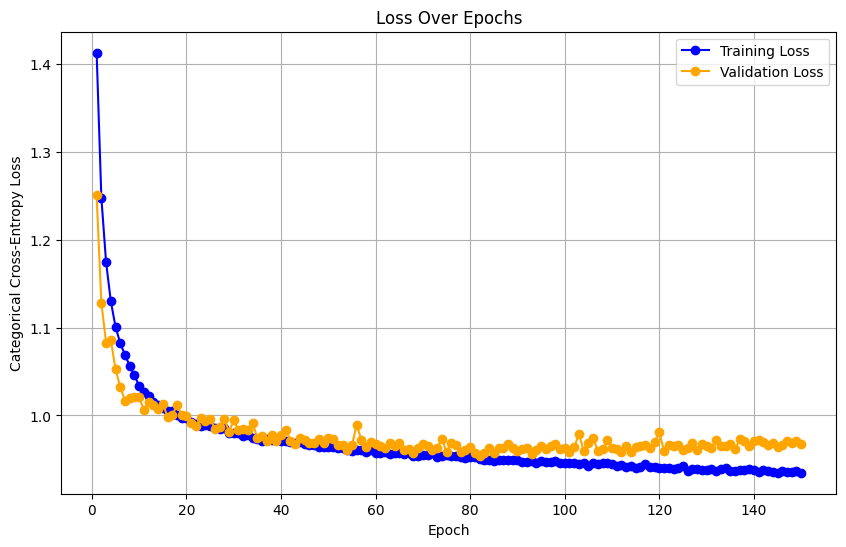

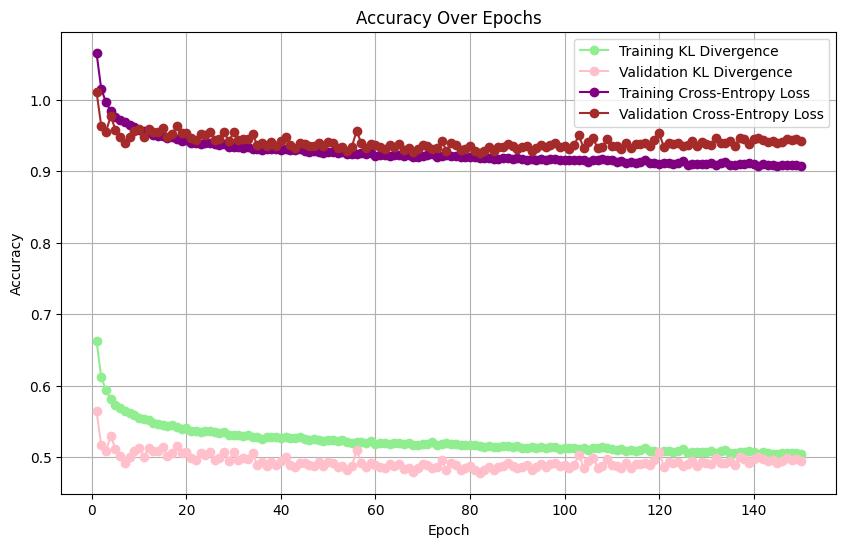

In [21]:
tf.keras.backend.clear_session()

model = build_model(lookback, n_cov_features, n_dt_features, n_states,
                    loss_type='digamma',
                    embedding_dim=2, rnn_units=32, n_dense_layers=1, dense_units=16,
                    dropout_rate=0.3, learning_rate=0.0001, l2_reg=0.001,
                    annealing_rate=100.0, max_annealing_rate=0)

history = model.fit(
    [X_train_cov_new, Y_month_train, horizon_train], Y_train_h,
    validation_data=([X_valid_cov_new, Y_month_valid, horizon_valid], Y_valid_h),
    callbacks=[AnnealingCallback()],
    epochs=150,  # Use the same number as in your tuner setup
    verbose=1  # Set to 0 for silent output if preferred
)
    
plot_training_history(history)

In [22]:
## Save the best model
model.save('energy_data/best_model_digamma.keras')
print("Model saved to energy_data/best_model_digamma.keras")

Model saved to energy_data/best_model_digamma.keras
